In [3]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

aln = ALNModel()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# plot uncontrolled dynamics, controlled dynamics
def plot_control(control_, target_ = aln.getZeroTarget(), filename = 'control_aln.png'):
    
    # no control
    aln.run()
    output_vars = aln.output_vars
    control_vars = aln.control_input_vars
    control_time_exc = - np.ones((2))
    control_time_inh = - np.ones((2))
    cntrl_limit_scaled = 10 * 1e-3
    cntrl_limit = cntrl_limit_scaled * 5. # 1e-3 nA (factor 5 because capacitance)
    
    
    
    for t in range(len(aln.t)):
        if (np.abs(control_[0,0,t]) > cntrl_limit and control_time_exc[0] == -1):
            control_time_exc[0] = aln.params.dt * t
        if (np.abs(control_[0,1,t]) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[0] = aln.params.dt * t
        if (control_time_exc[0] != -1 and control_time_inh[0] != -1):
            break
    for t in range(len(aln.t)-1, 0, -1):
        if (np.abs(control_[0,0,t]) > cntrl_limit and control_time_exc[1] == -1):
            control_time_exc[1] = aln.params.dt * t
        if (np.abs(control_[0,1,t]) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[1] = aln.params.dt * t
        if (control_time_exc[1] != -1 and control_time_inh[1] != -1):
            break

    fig, ax = plt.subplots(3, 3, figsize=(21, 15), linewidth=8, edgecolor='grey')
    plt.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.3, hspace=0.3)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]', 'Adaptation current [pA]']
    y_labels_control = ['Control exc. [nA]', 'Control inh. [nA]']
    sim_legend = ['Rate', 'Rate', 'Adaptation current']
    target_legend = ['Target']
    cntrl_time_legend = ['Control > {} pA'.format(cntrl_limit_scaled * 1000)]
    
    for i in range(len(output_vars)):
        ax[0,i].plot(aln.t, aln[output_vars[i]][0,:], label=sim_legend[i])
        ax[0,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[0,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[0,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    aln.run(control=control_)

    for i in range(len(output_vars)):
        ax[1,i].plot(aln.t, aln[output_vars[i]][0,:], label=sim_legend[i])
        ax[1,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[1,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[1,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    for i in range(len(control_vars)):
        ax[2,i].plot(aln.t, control_[0,i,:]/5.) # divide by five to take into account capacitance
        ax[2,i].set(xlabel='t [ms]', ylabel=y_labels_control[i])
    ax[2,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[2,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])

    if (target.any() != 0.):
        ax[0,0].plot(aln.t, target[0,0,:], '--', label=target_legend[0])
        ax[1,0].plot(aln.t, target[0,0,:], '--', label=target_legend[0])
        ax[0,1].plot(aln.t, target[0,1,:], '--', label=target_legend[0])
        ax[1,1].plot(aln.t, target[0,1,:], '--', label=target_legend[0])
        
        state = aln.getZeroState()
        for i in range(len(output_vars)):
            state[:,i,:] = aln[output_vars[i]][:,:]
        cost = aln.cost(state, target_, control_)
        
        ax[2,2].plot(aln.t, cost)
        ax[2,2].set(xlabel='t [ms]', ylabel='Cost')
        #ax[2,2].plot([-2.75, 1.01], [1.03, 1.03], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)
        #ax[2,2].plot([-0.2, -0.2], [3.45, -0.15], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)

    for i in range(3):
        for j in range(2):
            ax[i,j].legend(loc='upper right')
            
    rows = ['Uncontrolled', 'Controlled']
            
    for a, row in zip(ax[:,0], rows):
        a.annotate(row, xy=(-0.05, 0.5), xytext=(-a.yaxis.labelpad - 15, 0), rotation = 90,
                xycoords=a.yaxis.label, textcoords='offset points', size=20, ha='right', va='center', weight='bold')
        
    cols = ['Excitatory', 'Inhibitory']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.05), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=20, ha='center', va='baseline', weight='bold')
    
    plt.tight_layout()
    plt.savefig(filename)
    
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

[[9.0070e-05 2.6108e+01]
 [3.7674e+01 9.4217e+01]]


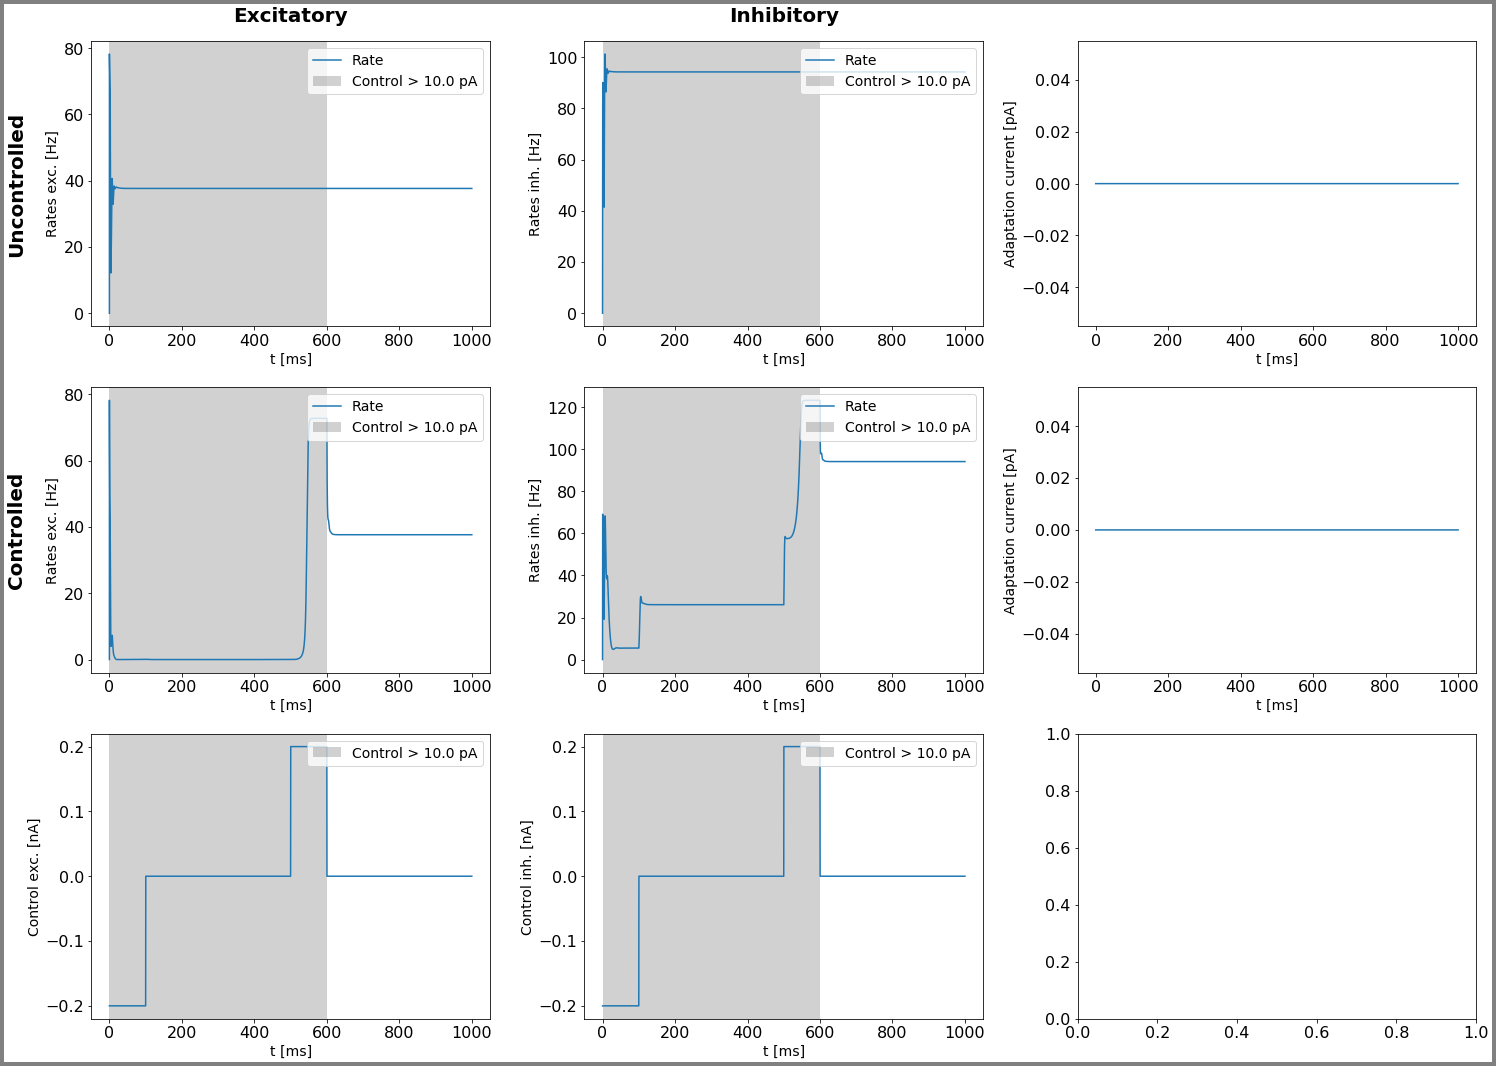

In [5]:
aln = ALNModel()

aln.params['duration'] = 1000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,1500:5000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,1500:5000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,6500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,6500:]) #high state inh

print(steady_rates)

plot_control(control0)

In [94]:
aln = ALNModel()
output = aln.output_vars

# 1 impacts 2
c_mat = np.array([[0, 0], [1, 0]])

# 2 impacts 1
#c_mat = np.array([[0, 1], [0, 0]])

# 1 impacts 2, 2 impacts 1
#c_mat = np.array([[0, 1], [1, 0]])

c_scheme = np.zeros((len(output), len(output) ))
c_scheme[0,0] = 1.

fiber_matrix = np.zeros((len(c_mat), len(c_mat)))
aln = ALNModel(Cmat = c_mat, Dmat = fiber_matrix)

u_mat = np.identity(aln.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

print("shape IA init = ", aln.params["IA_init"].shape)
print("shape rates_exc_init = ", aln.params["rates_exc_init"].shape)

for init in aln.init_vars:
    aln.params[init] = np.zeros(aln.params[init].shape)

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

aln.params.rates_exc_init = np.array([[0.], [0.]])
aln.params.rates_inh_init = np.array([[0.], [0.]])   
    
aln.params['duration'] = 30.

control0 = aln.getZeroControl()
#control0[:,0,300:350] = -2.
#control0[:,0,600:650] = 3.

target = aln.getZeroTarget()
target[:,0,:] = steady_rates[1,0]
target[:,1,:] = steady_rates[1,1]

shape IA init =  (2, 1)
shape rates_exc_init =  (2, 1)


In [95]:
aln.params.c_gl = 1.
aln.params.ext_exc_current = np.array([[2.3], [0]])
aln.params.ext_inh_current = np.array([[2.5], [0]])

starting rate =  [0. 0.]
External current: exc =  [[2.3]
 [0. ]] , inh =  [[2.5]
 [0. ]]


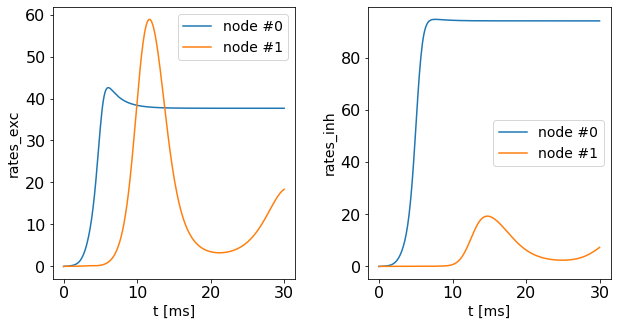

In [96]:
#aln.run(control=control0)
aln.run()

print("starting rate = ", aln.rates_exc[:,0])
print("External current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)

fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for n in range(aln.params.N):
    for i in range(2):
        ax[i].plot(aln.t, aln[output[i]][n,:], label="node #{}".format(n))
        ax[i].legend()
        ax[i].set(xlabel='t [ms]', ylabel=output[i])
    #ax[2].plot(aln[output[0]][n,:], aln[output[1]][n,:])
plt.show()

In [118]:
max_it = 100
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 1000.
test_step = 1e-6

cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

control0 = aln.getZeroControl()
control0[1,0,:] = 2.3
control0[1,1,:] = 2.5

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl)

set cost params
RUN  0 , total integrated cost:  43075.580547227444
RUN  1 , total integrated cost:  21601.952827952027
RUN  2 , total integrated cost:  19573.99652385276
RUN  3 , total integrated cost:  18998.736334559395
RUN  4 , total integrated cost:  18807.95922572186
RUN  5 , total integrated cost:  18728.044688081565
RUN  6 , total integrated cost:  18698.13217851046
RUN  7 , total integrated cost:  18679.143961285296
RUN  8 , total integrated cost:  18673.272922109787
RUN  9 , total integrated cost:  18662.51831507191
RUN  10 , total integrated cost:  18659.00338569663
RUN  11 , total integrated cost:  18656.893679556088
RUN  12 , total integrated cost:  18655.7468782597
RUN  13 , total integrated cost:  18655.21549897426
RUN  14 , total integrated cost:  18654.642514497602
RUN  15 , total integrated cost:  18654.360894085316
RUN  16 , total integrated cost:  18654.30387268008
RUN  17 , total integrated cost:  18654.255571327896
RUN  18 , total integrated cost:  18654.221967602

RUN  26 , total integrated cost:  18654.08678881815
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

...

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  95 , total integrated cost:  18654.03894836619
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

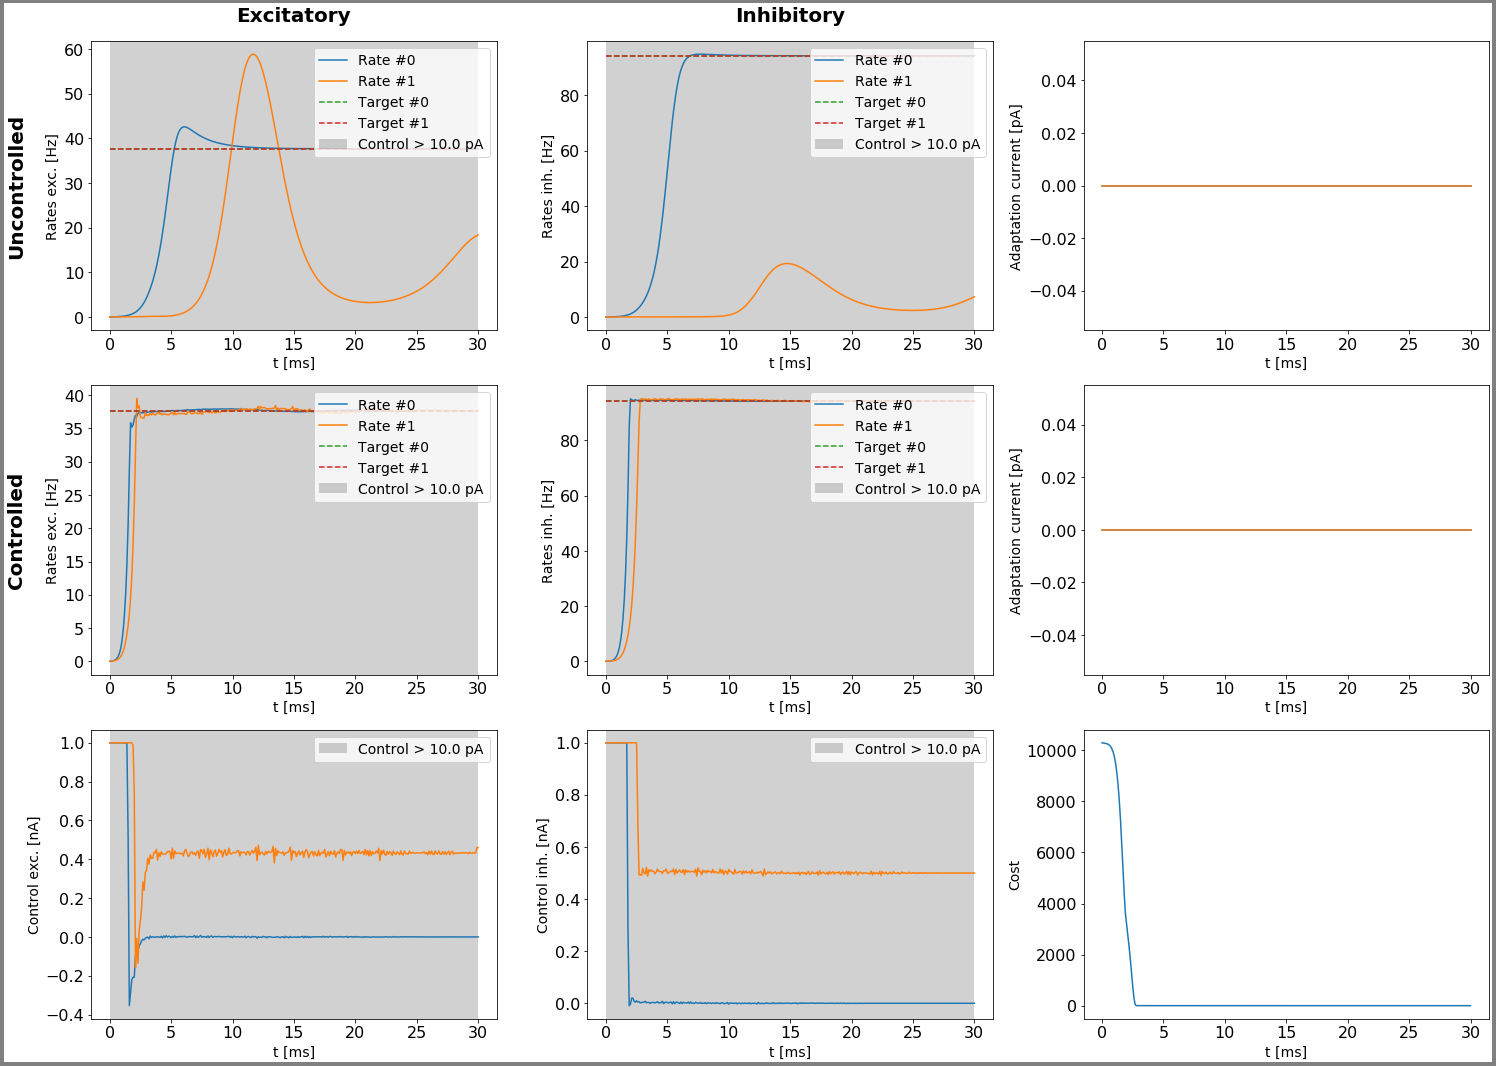

In [111]:
plot_control_network(A2_bestControlA, target, filename = 'networkA.png')

In [112]:
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

control0 = aln.getZeroControl()

A2_bestControlB, A2_bestStateB, A2_costB, A2_runtimeB = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl)

set cost params
RUN  0 , total integrated cost:  154409.04861531206
RUN  1 , total integrated cost:  72835.89444288654
RUN  2 , total integrated cost:  39365.82413852633
RUN  3 , total integrated cost:  37351.67919836731
RUN  4 , total integrated cost:  34942.34525226373
RUN  5 , total integrated cost:  33417.559640509615
RUN  6 , total integrated cost:  32335.051642372735
RUN  7 , total integrated cost:  31221.995935862153
RUN  8 , total integrated cost:  30169.352158939277
RUN  9 , total integrated cost:  29194.957176685613
RUN  10 , total integrated cost:  28459.346977345467
Improved over  10  iterations by  82  percent.


In [114]:
A2_bestControlB1, A2_bestStateB1, A2_costB1, A2_runtimeB1 = aln.A2(A2_bestControlB, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl)

RUN  0 , total integrated cost:  28459.346977345467
RUN  1 , total integrated cost:  27778.631371217725
RUN  2 , total integrated cost:  27076.165636797083
RUN  3 , total integrated cost:  26364.24587800345
RUN  4 , total integrated cost:  25600.678447364127
RUN  5 , total integrated cost:  24898.904603527288
RUN  6 , total integrated cost:  24211.63911394841
RUN  7 , total integrated cost:  23574.87136776607
RUN  8 , total integrated cost:  22912.55708218218
RUN  9 , total integrated cost:  22255.419024181752
RUN  10 , total integrated cost:  21585.365285950258
Improved over  10  iterations by  25  percent.


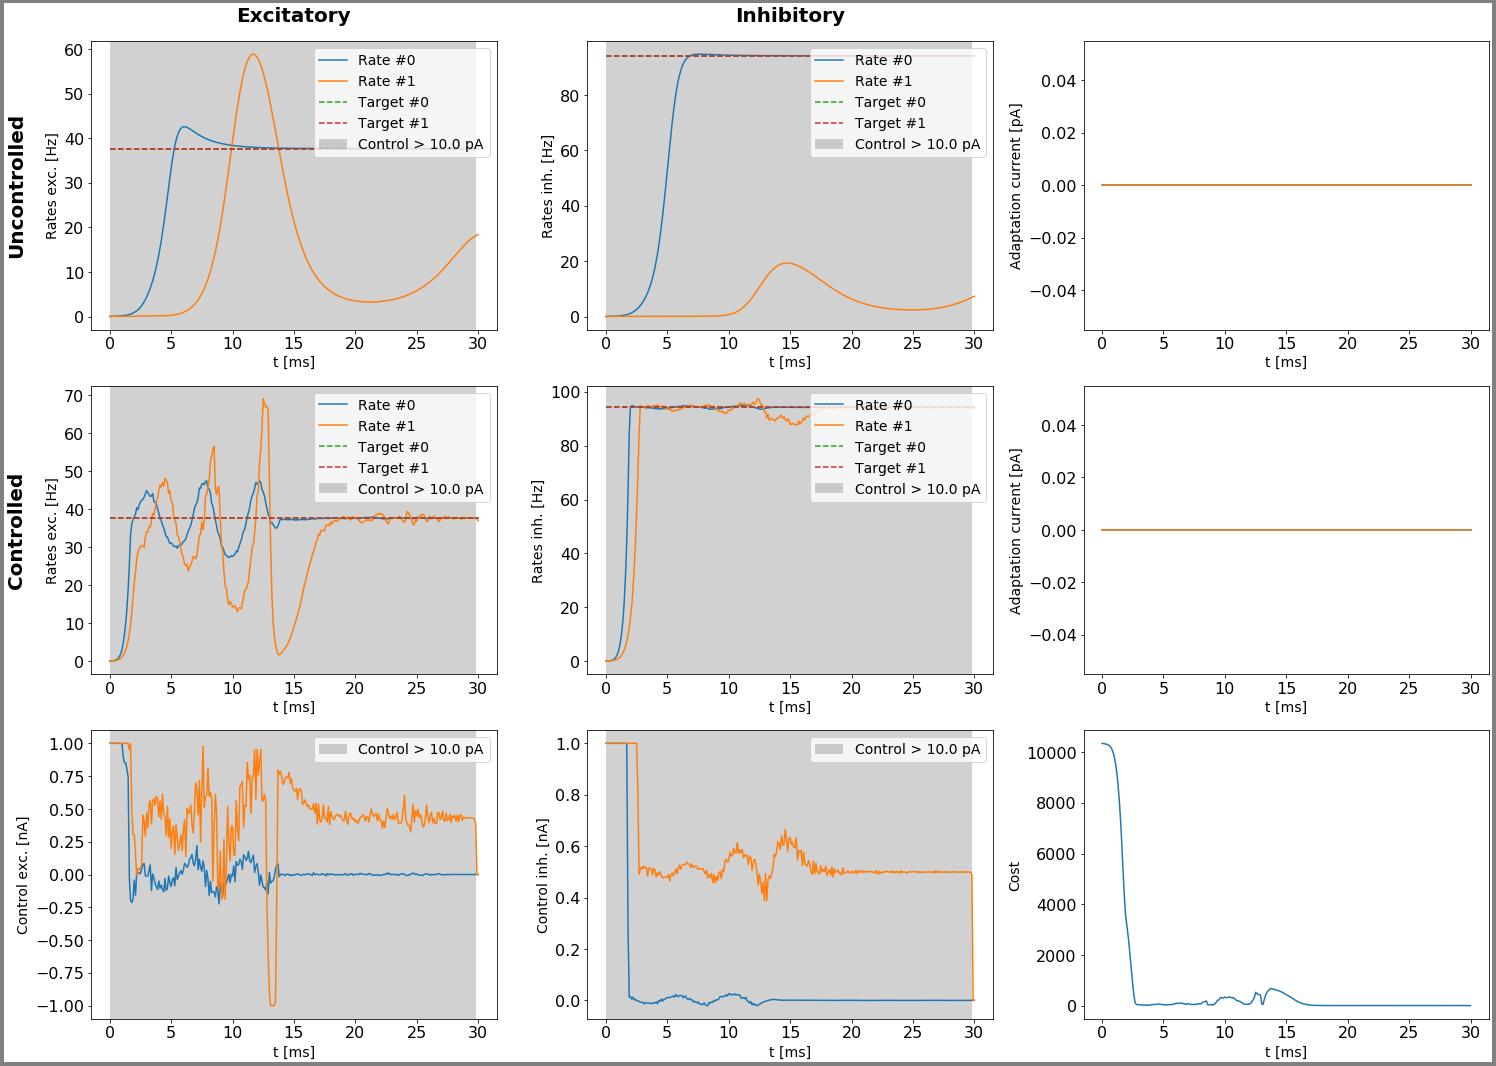

In [115]:
plot_control_network(A2_bestControlB1, target, filename = 'networkB.png')

In [116]:
A2_bestControlB2, A2_bestStateB2, A2_costB2, A2_runtimeB2 = aln.A2(A2_bestControlB1, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl)

RUN  0 , total integrated cost:  21585.365285950258
RUN  1 , total integrated cost:  20900.38702351647
RUN  2 , total integrated cost:  20437.559613255697
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  3 , total integrated cost:  20134.409474865337
 max iteratio

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  7 , total integrated cost:  19580.20111831575
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

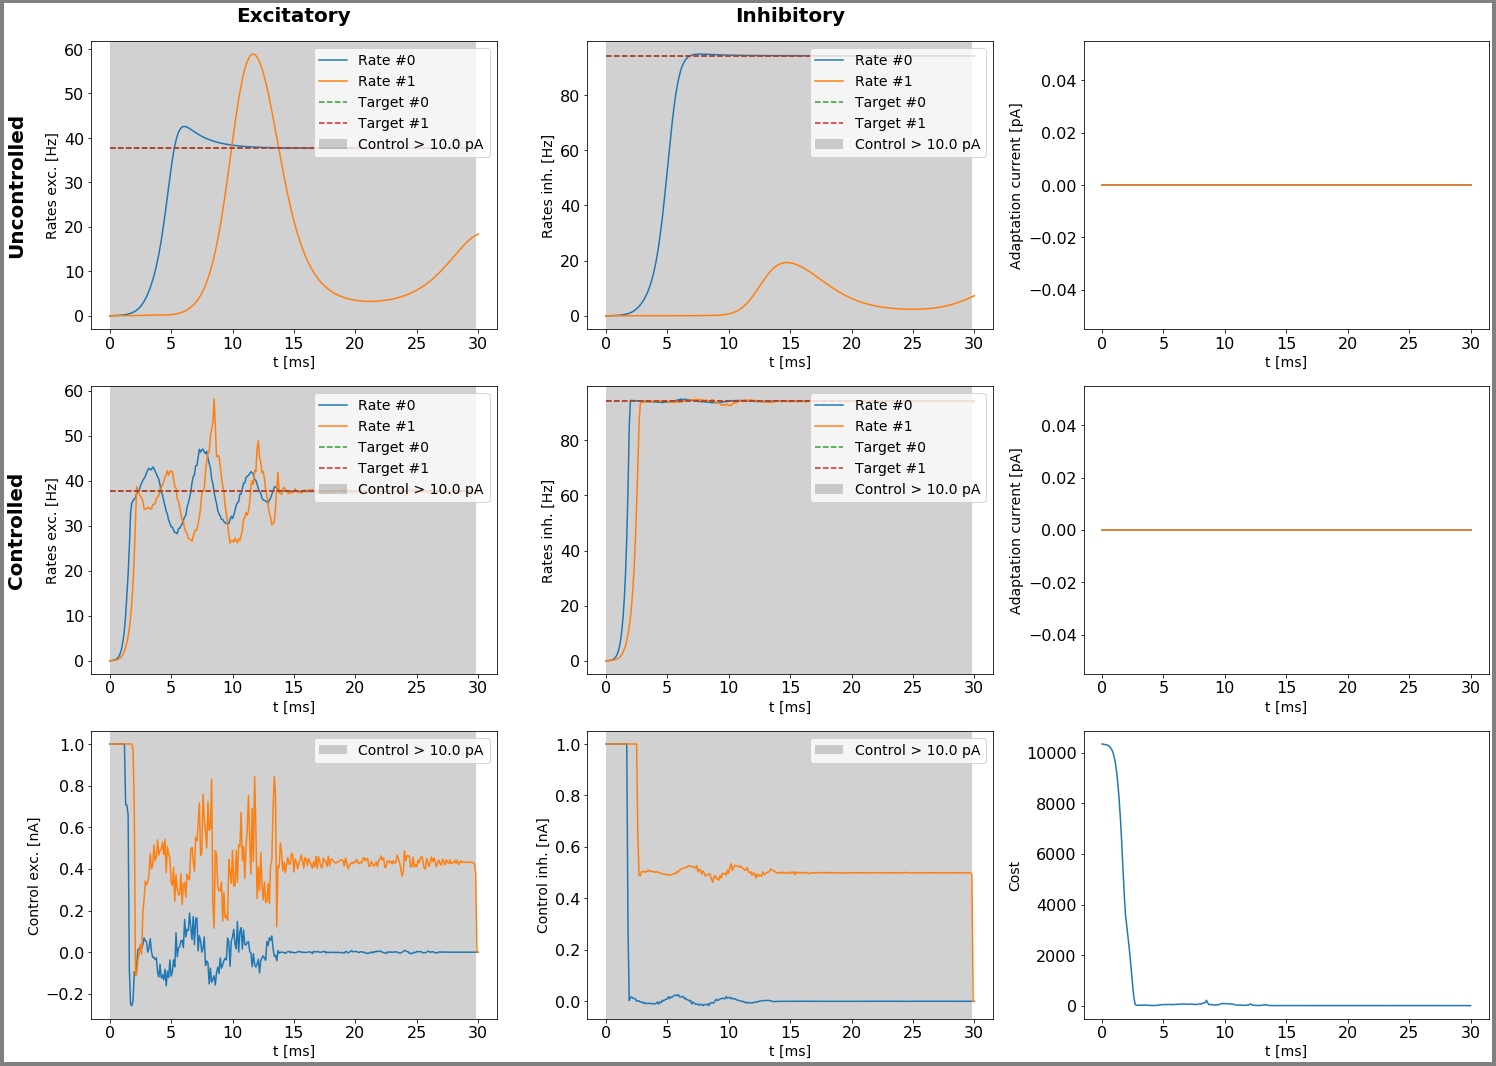

In [117]:
plot_control_network(A2_bestControlB2, target, filename = 'networkB.png')

In [103]:
def plot_control_network(control_, target_ = aln.getZeroTarget(), filename = 'control_aln.png'):
    
    # no control
    aln.run()
    output_vars = aln.output_vars
    control_vars = aln.control_input_vars
    control_time_exc = - np.ones((2))
    control_time_inh = - np.ones((2))
    cntrl_limit_scaled = 10 * 1e-3
    cntrl_limit = cntrl_limit_scaled * 5. # 1e-3 nA (factor 5 because capacitance)
    
    
    
    for t in range(len(aln.t)):
        if (np.abs(any(control_[:,0,t])) > cntrl_limit and control_time_exc[0] == -1):
            control_time_exc[0] = aln.params.dt * t
        if (np.abs(any(control_[:,1,t])) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[0] = aln.params.dt * t
        if (control_time_exc[0] != -1 and control_time_inh[0] != -1):
            break
    for t in range(len(aln.t)-1, 0, -1):
        if (np.abs(any(control_[:,0,t])) > cntrl_limit and control_time_exc[1] == -1):
            control_time_exc[1] = aln.params.dt * t
        if (np.abs(any(control_[:,1,t])) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[1] = aln.params.dt * t
        if (control_time_exc[1] != -1 and control_time_inh[1] != -1):
            break

    fig, ax = plt.subplots(3, 3, figsize=(21, 15), linewidth=8, edgecolor='grey')
    plt.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.3, hspace=0.3)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]', 'Adaptation current [pA]']
    y_labels_control = ['Control exc. [nA]', 'Control inh. [nA]']
    sim_legend = ['Rate #{}', 'Rate #{}', 'Adaptation current #{}']
    target_legend = ['Target #{}']
    cntrl_time_legend = ['Control > {} pA'.format(cntrl_limit_scaled * 1000)]
    
    for i in range(len(output_vars)):
        for n in range(aln.params["N"]):
            ax[0,i].plot(aln.t, aln[output_vars[i]][n,:], label=sim_legend[i].format(n))
        ax[0,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[0,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[0,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    aln.run(control=control_)

    for i in range(len(output_vars)):
        for n in range(aln.params["N"]):
            ax[1,i].plot(aln.t, aln[output_vars[i]][n,:], label=sim_legend[i].format(n))
        ax[1,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[1,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[1,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    for i in range(len(control_vars)):
        for n in range(aln.params["N"]):
            ax[2,i].plot(aln.t, control_[n,i,:]/5.) # divide by five to take into account capacitance
        ax[2,i].set(xlabel='t [ms]', ylabel=y_labels_control[i])
    ax[2,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[2,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])

    if (target.any() != 0.):
        for i in range(2):
            for j in range(2):
                for n in range(aln.params["N"]):
                    ax[i,j].plot(aln.t, target[n,j,:], '--', label=target_legend[0].format(n))
        
        state = aln.getZeroState()
        for i in range(len(output_vars)):
            state[:,i,:] = aln[output_vars[i]][:,:]
        cost = aln.cost(state, target_, control_)
        
        ax[2,2].plot(aln.t, cost)
        ax[2,2].set(xlabel='t [ms]', ylabel='Cost')
        #ax[2,2].plot([-2.75, 1.01], [1.03, 1.03], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)
        #ax[2,2].plot([-0.2, -0.2], [3.45, -0.15], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)

    for i in range(3):
        for j in range(2):
            ax[i,j].legend(loc='upper right')
            
    rows = ['Uncontrolled', 'Controlled']
            
    for a, row in zip(ax[:,0], rows):
        a.annotate(row, xy=(-0.05, 0.5), xytext=(-a.yaxis.labelpad - 15, 0), rotation = 90,
                xycoords=a.yaxis.label, textcoords='offset points', size=20, ha='right', va='center', weight='bold')
        
    cols = ['Excitatory', 'Inhibitory']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.05), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=20, ha='center', va='baseline', weight='bold')
    
    plt.tight_layout()
    plt.savefig(filename)